# Class 6: FDE Data Validation with FlashEats (solved)

Yesterday, you proved you could **retrieve** data from multiple systems.

Today the question is different:

> **Can we safely use that data to make a business decision?**

This is not a generic data-cleaning lab.

## FDE validation mindset

**Business claim → assumptions → validation contract → targeted checks → stakeholder clarification → PASS / WARN / FAIL → publish decision**

### Concepts

**1. Validation is decision-dependent**
A field can be good enough for weekly reporting but unsafe for a live operational decision.

**2. Turn assumptions into contracts**
Business assumption → data expectation → executable check → action.

**3. Separate three validation types**
- Technical: chronology, IDs, categories, mappings
- Semantic: what does a status or ETA actually mean?
- Organizational: who owns the KPI definition?

**4. Never silently fix ambiguity**
Do not encode thresholds or category mappings without ownership.

**5. Output a validation gate**
The deliverable is not merely a cleaned dataframe. It is a decision:
PASS / WARN / FAIL / UNKNOWN.

> **How to run:** the FlashEats classroom pack is the instructor's material and is not in this repo. Put it in `Code/` at the repo root (so `Code/database/flasheats.db` exists), install `pandas matplotlib`, then run top to bottom.

In [1]:
import json
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

# Local run: look in the current folder, then in the repo's Code/ folder
def find_pack_root():
    for candidate in [Path.cwd(), Path.cwd() / "Code", Path.cwd().parent / "Code"]:
        if (candidate / "database" / "flasheats.db").exists():
            return candidate
    return None

BASE = find_pack_root()
if BASE is None:
    raise FileNotFoundError("FlashEats pack not found. Put it in Code/ at the repo root.")

DB_PATH = BASE / "database" / "flasheats.db"
print("Database exists:", DB_PATH.exists())

Database exists: True


## Load the updated FlashEats data

In [2]:
con = sqlite3.connect(BASE / "database" / "flasheats.db")

orders = pd.read_sql("SELECT * FROM orders", con)
restaurants = pd.read_sql("SELECT * FROM restaurants", con)
drivers = pd.read_sql("SELECT * FROM drivers", con)
customers = pd.read_sql("SELECT * FROM customers", con)

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")

with open(BASE / "data" / "client_metric_definitions.json", "r") as f:
    metric_notes = json.load(f)

print("orders:", orders.shape)
print("tickets:", tickets.shape)
print("restaurant_status:", restaurant_status.shape)

display(orders.head())
display(tickets.head())
display(restaurant_status.head())
print(json.dumps(metric_notes, indent=2))

orders: (1603, 13)
tickets: (202, 5)
restaurant_status: (502, 4)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


,order_id,restaurant_id,status,last_updated_at
0,O00676,R040,READY,2026-08-17T13:29:00
1,O01506,R055,Ready,2026-08-27T16:37:00
2,O01484,R032,ready,2026-08-08T19:44:00
3,O00675,R012,handoff,2026-08-22T21:42:00
4,O00078,R027,unknown,2026-08-25T19:35:00


{
  "metric_under_review": "Late Delivery Rate",
  "leadership_claim": "Late Delivery Rate is 56%",
  "stakeholders": {
    "VP Operations": "Any delivered order after the promised ETA is late.",
    "Support Lead": "Only more than 10 minutes beyond ETA should count as meaningfully late.",
    "Finance": "Cancelled/refunded orders should not count in operational performance.",
    "Data Team": "Historical dashboard uses delivered orders with non-null actual delivery time."
  },
  "note": "No canonical KPI owner is formally documented."
}


# Challenge 1: Can we defend the "56% late" claim?

Leadership says:

> **"Late Delivery Rate is 56%."**

Before calculating anything, create a validation contract.

| Business assumption | Data expectation | How will you test it? | Severity if false |
|---|---|---|---|
| One row = one business order | `order_id` is unique | `nunique()` vs `len()`; compare the duplicate copies | Medium: an order counted twice |
| Delivered orders have completion time | `actual_delivery_at` not null when delivered | count delivered rows with a null delivery time | High: those orders cannot be classed late or on time |
| Promised ETA is valid | `promised_eta >= created_at` | compare the two columns | High: an ETA before the order existed makes its delay meaningless |
| Event chronology is valid | `created_at <= pickup_at <= actual_delivery_at` | compare each pair | High for delay analysis, low for the headline rate |
| "Late" has an agreed definition | one written definition with a named owner | read `client_metric_definitions.json` | **Blocking**: without it there is no single number to publish |

**Hint:** Don't start by cleaning. Ask: *what could make 56% misleading?*

In [3]:
print("Rows:", len(orders))
print("Unique orders:", orders["order_id"].nunique())
print(orders["final_status"].value_counts(dropna=False))

Rows: 1603
Unique orders: 1600
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64


In [4]:
# Business grain: do the duplicate copies agree with each other?
dupes = orders[orders["order_id"].duplicated(keep=False)].sort_values("order_id")
cols_that_differ = [c for c in orders.columns
                    if dupes.groupby("order_id")[c].nunique(dropna=False).gt(1).any()]
print("Duplicated orders:", dupes["order_id"].nunique(), "| columns where the copies disagree:", cols_that_differ)
display(dupes[["order_id", "final_status", "actual_delivery_at", "traffic_bucket"]])

Duplicated orders: 3 | columns where the copies disagree: ['traffic_bucket']


,order_id,final_status,actual_delivery_at,traffic_bucket
119,O00120,delivered,2026-08-13T19:34:08.431508,severe
1600,O00120,delivered,2026-08-13T19:34:08.431508,medium
722,O00723,delivered,2026-08-05T22:04:30.928322,medium
1601,O00723,delivered,2026-08-05T22:04:30.928322,high
1301,O01302,delivered,2026-08-26T22:20:27.428561,medium
1602,O01302,delivered,2026-08-26T22:20:27.428561,high


In [5]:
# Chronology checks, on one row per order (flags, not deletions)
chk = orders.drop_duplicates("order_id", keep="first").copy()
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    chk[c] = pd.to_datetime(chk[c], format="mixed", errors="coerce")
chk["status"] = chk["final_status"].str.strip().str.lower()

rules = {
    "delivered but no actual_delivery_at": (chk["status"] == "delivered") & chk["actual_delivery_at"].isna(),
    "promised_eta before created_at": chk["promised_eta"] < chk["created_at"],
    "pickup_at before created_at": chk["pickup_at"] < chk["created_at"],
    "actual_delivery_at before pickup_at": chk["actual_delivery_at"] < chk["pickup_at"],
    "cancelled but has pickup_at": (chk["status"] == "cancelled") & chk["pickup_at"].notna(),
}
contract = pd.DataFrame([{"rule": name, "violations": int(mask.sum()),
                          "example orders": ", ".join(chk.loc[mask, "order_id"].head(5))}
                         for name, mask in rules.items()])
contract

,rule,violations,example orders
0,delivered but no actual_delivery_at,37,"O00043, O00095, O00127, O00206, O00286"
1,promised_eta before created_at,4,"O00101, O00102, O00103, O00104"
2,pickup_at before created_at,0,
3,actual_delivery_at before pickup_at,5,"O00051, O00052, O00053, O00054, O00055"
4,cancelled but has pickup_at,68,"O00004, O00017, O00075, O00129, O00154"


In [6]:
# What do these problems do to 56%?
valid = chk[(chk["status"] == "delivered") & chk["actual_delivery_at"].notna()].copy()
valid["delay_min"] = (valid["actual_delivery_at"] - valid["promised_eta"]).dt.total_seconds() / 60
bad_chronology = rules["promised_eta before created_at"] | rules["actual_delivery_at before pickup_at"]
n, late, missing = len(valid), int((valid["delay_min"] > 0).sum()), int(rules["delivered but no actual_delivery_at"].sum())

pd.Series({
    "headline: late / valid delivered": f"{late} / {n} = {100 * late / n:.1f}%",
    "without the 9 chronology violators": f"{100 * (valid.loc[~bad_chronology.reindex(valid.index), 'delay_min'] > 0).mean():.1f}%",
    "if none of the 37 undated were late": f"{100 * late / (n + missing):.1f}%",
    "if all of the 37 undated were late": f"{100 * (late + missing) / (n + missing):.1f}%",
    "4 largest delays have an impossible ETA": bool(valid.nlargest(4, "delay_min")["order_id"]
                                                   .isin(chk.loc[rules["promised_eta before created_at"], "order_id"]).all()),
}).to_frame("result")

,result
headline: late / valid delivered,843 / 1495 = 56.4%
without the 9 chronology violators,56.3%
if none of the 37 undated were late,55.0%
if all of the 37 undated were late,57.4%
4 largest delays have an impossible ETA,True


**Challenge 1 answer.** 56% is **arithmetically reproducible** (843 of 1,495 = 56.4%), and the data problems move it only a little: 56.3% without the 9 chronology violators, and between 55.0% and 57.4% depending on the 37 delivered orders with no completion time. What makes "56%" misleading is not the arithmetic:

- **Grain:** 3 orders appear twice and the copies disagree on `traffic_bucket`. Harmless for the rate, wrong for any traffic analysis.
- **Chronology:** 4 orders were "promised" 10 minutes before they were created, and they are the 4 largest delays in the table. 5 orders were delivered before pickup. These must be quarantined, not averaged.
- **Semantics:** all 68 cancelled orders have a pickup time, so "cancelled" may mean after pickup. Someone must say what it means.
- **Definition:** leadership has not said which "late" the 56% is (Challenge 2). That is the real blocker.

# Challenge 2: Stakeholders disagree on "late"

Read `client_metric_definitions.json`.

Calculate the metric under at least three definitions:
- any delay > 0 minutes,
- delay > 10 minutes,
- historical-style delivered/non-null population.

Then answer:

> **Which one should leadership publish, and who must own that decision?**

In [7]:
analysis = orders.drop_duplicates("order_id", keep="first").copy()

for c in ["promised_eta", "actual_delivery_at"]:
    analysis[c] = pd.to_datetime(analysis[c], format="mixed", errors="coerce")

analysis["delay_min"] = (
    analysis["actual_delivery_at"] - analysis["promised_eta"]
).dt.total_seconds() / 60

analysis["status"] = analysis["final_status"].str.strip().str.lower()
delivered_dated = analysis[(analysis["status"] == "delivered") & analysis["actual_delivery_at"].notna()]
historical = analysis[analysis["actual_delivery_at"].notna()]   # Data Team: non-null delivery time

def rate(name, population, condition, meaning):
    late = int(condition.sum())
    return {"definition": name, "late": late, "population": len(population),
            "late rate %": round(100 * late / len(population), 1), "business meaning": meaning}

definitions = pd.DataFrame([
    rate("VP Ops: any delay > 0 min", delivered_dated, delivered_dated["delay_min"] > 0,
         "Strict: any second past the promise"),
    rate("Support: delay > 10 min", delivered_dated, delivered_dated["delay_min"] > 10,
         "Lateness a customer would notice"),
    rate("Data Team: historical delivered / non-null", historical, historical["delay_min"] > 0,
         "What the existing dashboard shows"),
    rate("Finance: exclude cancelled / refunded", delivered_dated, delivered_dated["delay_min"] > 0,
         "Cancelled already excluded; no refund field exists"),
    rate("Naive: every unique order as denominator", analysis, analysis["delay_min"] > 0,
         "Wrong: cancelled and undated orders count as on time"),
])
definitions

,definition,late,population,late rate %,business meaning
0,VP Ops: any delay > 0 min,843,1495,56.4,Strict: any second past the promise
1,Support: delay > 10 min,349,1495,23.3,Lateness a customer would notice
2,Data Team: historical delivered / non-null,843,1495,56.4,What the existing dashboard shows
3,Finance: exclude cancelled / refunded,843,1495,56.4,Cancelled already excluded; no refund field exists
4,Naive: every unique order as denominator,843,1600,52.7,Wrong: cancelled and undated orders count as on time


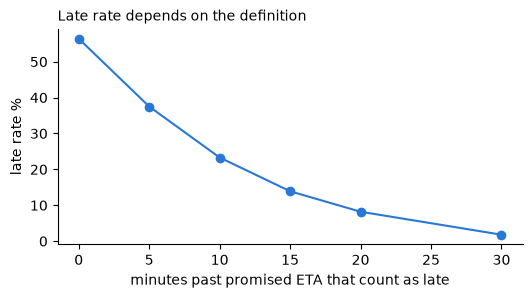

,0,5,10,15,20,30
late rate %,56.4,37.5,23.3,13.9,8.2,1.8


In [8]:
# The threshold moves the number far more than any data problem
thresholds = [0, 5, 10, 15, 20, 30]
curve = pd.Series({t: 100 * (delivered_dated["delay_min"] > t).mean() for t in thresholds}).round(1)
ax = curve.plot(marker="o", figsize=(6, 2.8), color="#2a78d6")
ax.set_xlabel("minutes past promised ETA that count as late"); ax.set_ylabel("late rate %")
ax.set_title("Late rate depends on the definition", loc="left", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.show()
curve.rename("late rate %").to_frame().T

**Challenge 2 answer.** The same data gives **56.4%** (VP Ops, Data Team and Finance populations coincide here), **23.3%** (Support's 10 minute threshold), or **52.7%** (a naive denominator). Note that the Data Team rule is a *population* rule, not a threshold, which is why it gives the same 56.4%; and Finance's "refunded" cannot be applied at all because no refund field exists.

**What leadership should publish:** not a bare "56%". Publish the number *with its definition attached*, for example: "56.4% of delivered orders with a recorded delivery time arrived after the original promised ETA (843 of 1,495)", with the more-than-10-minutes figure (23.3%) beside it as the customer-visible measure.

**Who owns it:** the client's own file says *"No canonical KPI owner is formally documented."* That is itself a finding. Leadership must name an owner. A sensible split: VP Operations proposes the definition, Support and Finance sign off, and the Data Team implements and documents it. This is an organizational question the data cannot answer.

# Challenge 3: Validate categories without cleaning by instinct

Inspect:
- `final_status`
- `traffic_bucket`
- restaurant `status`
- support-ticket `category`

For each:
1. list observed values,
2. identify representation differences,
3. decide what is safe to normalize,
4. identify what requires owner confirmation.

Remember:

> `"Delivered"` vs `"delivered"` is likely representation.
> `"handoff"` vs `"handed_off"` may be semantics.

In [9]:
for col in ["final_status", "traffic_bucket"]:
    print("\n", col)
    print(orders[col].value_counts(dropna=False))

print("\nRestaurant status")
print(restaurant_status["status"].value_counts(dropna=False))

print("\nSupport category")
print(tickets["category"].value_counts(dropna=False))


 final_status
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64

 traffic_bucket
traffic_bucket
medium    635
high      448
low       381
severe    136
HIGH        3
Name: count, dtype: int64

Restaurant status
status
preparing     171
handed_off    168
ready         157
ready           2
READY           1
Ready           1
handoff         1
unknown         1
Name: count, dtype: int64

Support category
category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64


In [10]:
# Show each raw value with repr(), so invisible trailing spaces become visible,
# next to the value it would become under a representation-only fix (strip + lowercase)
def category_profile(series):
    raw = series.value_counts(dropna=False).rename("rows").reset_index()
    raw.columns = ["raw value", "rows"]
    raw["raw value"] = raw["raw value"].map(repr)
    raw["strip + lower"] = series.value_counts(dropna=False).index.str.strip().str.lower()
    return raw

for name, s in [("orders.final_status", orders["final_status"]),
                ("orders.traffic_bucket", orders["traffic_bucket"]),
                ("restaurant_status.status", restaurant_status["status"]),
                ("support_tickets.category", tickets["category"])]:
    profile = category_profile(s)
    print(f"{name}: {len(profile)} raw values -> {profile['strip + lower'].nunique()} after strip + lower")
    display(profile)

orders.final_status: 3 raw values -> 2 after strip + lower


,raw value,rows,strip + lower
0,'delivered',1530,delivered
1,'cancelled',68,cancelled
2,'Delivered',5,delivered


orders.traffic_bucket: 5 raw values -> 4 after strip + lower


,raw value,rows,strip + lower
0,'medium',635,medium
1,'high',448,high
2,'low',381,low
3,'severe',136,severe
4,'HIGH',3,high


restaurant_status.status: 8 raw values -> 5 after strip + lower


,raw value,rows,strip + lower
0,'preparing',171,preparing
1,'handed_off',168,handed_off
2,'ready',157,ready
3,'ready ',2,ready
4,'READY',1,ready
5,'Ready',1,ready
6,'handoff',1,handoff
7,'unknown',1,unknown


support_tickets.category: 9 raw values -> 8 after strip + lower


,raw value,rows,strip + lower
0,'late_delivery',38,late_delivery
1,'eta_changed',37,eta_changed
2,'restaurant_delay',37,restaurant_delay
3,'ready_but_waiting',33,ready_but_waiting
4,'status_mismatch',29,status_mismatch
5,'driver_not_moving',25,driver_not_moving
6,'Late Delivery',1,late delivery
7,'late_delivery ',1,late_delivery
8,'ETA issue',1,eta issue


In [11]:
# A category can disagree with its own ticket text: that is semantics, not spelling
tickets["category_norm"] = tickets["category"].str.strip().str.lower()
display(tickets.groupby("category_norm")["customer_message"].unique().to_frame())
display(tickets[tickets["category"].isin(["Late Delivery", "ETA issue"])][["ticket_id", "category", "customer_message"]])

,customer_message
category_norm,
driver_not_moving,[The rider has not moved for 15 minutes.]
eta issue,[The rider has not moved for 15 minutes.]
eta_changed,[The ETA keeps changing and the food is still not here.]
late delivery,[The rider has not moved for 15 minutes.]
late_delivery,[My order is already past the promised time.]
ready_but_waiting,[Restaurant says food is ready but no rider has picked it up.]
restaurant_delay,[Restaurant says they are still preparing my order.]
status_mismatch,[The app says picking up but the restaurant says it is ready.]


,ticket_id,category,customer_message
3,T00004,Late Delivery,The rider has not moved for 15 minutes.
5,T00006,ETA issue,The rider has not moved for 15 minutes.


**Challenge 3 answer.**

| Column | Observed values | Safe to normalize (representation) | Needs owner confirmation (semantics) |
|---|---|---|---|
| `orders.final_status` | `delivered` 1,530, `cancelled` 68, `Delivered` 5 | `Delivered` → `delivered` (case only) | Does `cancelled` happen after pickup? All 68 have a pickup time |
| `orders.traffic_bucket` | `medium`, `high`, `low`, `severe`, `HIGH` 3 | `HIGH` → `high` | What separates `high` from `severe` (the bucket boundaries) |
| `restaurant_status.status` | `preparing`, `handed_off`, `ready`, plus `'ready '` 2, `READY` 1, `Ready` 1, `handoff` 1, `unknown` 1 | the four `ready` variants → `ready` (case and whitespace) | `handoff` vs `handed_off`: typo or a different state? `unknown`: a real state or a system default? |
| `support_tickets.category` | six clean values, plus `Late Delivery` 1, `'late_delivery '` 1, `ETA issue` 1 | `'late_delivery '` → `late_delivery` (whitespace only) | `Late Delivery` (T00004) looks like a spelling variant, but its message is "The rider has not moved", as is `ETA issue` (T00006). Is the label or the message right? Is `ETA issue` the same as `eta_changed`? |

Rule applied: we normalize **only** case and whitespace. Anything that changes meaning (`handoff`, `unknown`, `ETA issue`) is left as is and sent to its owner, not mapped by instinct.

# Challenge 4: Cross-source integrity

Validate mappings:
- `orders.restaurant_id` → restaurants
- `orders.driver_id` → drivers
- `tickets.order_id` → orders
- `restaurant_status.order_id` → orders

Then discuss:

> If 1% is unmapped, is that acceptable?

It depends on which business decision uses those records.

In [12]:
# Example:
# orders["restaurant_id"].dropna().isin(restaurants["restaurant_id"]).mean()
# Careful: .dropna() throws null keys away before measuring, so that line reports 100%.
# We count null keys and unmapped keys separately.

def coverage(name, child, parent):
    total, nulls = len(child), int(child.isna().sum())
    mapped = int(child.dropna().isin(set(parent)).sum())   # set = hash lookup, one pass
    unmapped = total - nulls - mapped
    status = "PASS" if nulls == 0 and unmapped == 0 else ("FAIL" if unmapped else "WARN")
    return {"relationship": name, "rows": total, "null key": nulls, "non-null but unmapped": unmapped,
            "coverage % (all rows)": round(100 * mapped / total, 2), "status": status}

mapping = pd.DataFrame([
    coverage("orders.restaurant_id → restaurants", orders["restaurant_id"], restaurants["restaurant_id"]),
    coverage("orders.driver_id → drivers", orders["driver_id"], drivers["driver_id"]),
    coverage("orders.customer_id → customers", orders["customer_id"], customers["customer_id"]),
    coverage("tickets.order_id → orders", tickets["order_id"], orders["order_id"]),
    coverage("restaurant_status.order_id → orders", restaurant_status["order_id"], orders["order_id"]),
])
mapping

,relationship,rows,null key,non-null but unmapped,coverage % (all rows),status
0,orders.restaurant_id → restaurants,1603,3,0,99.81,WARN
1,orders.driver_id → drivers,1603,3,0,99.81,WARN
2,orders.customer_id → customers,1603,0,0,100.00,PASS
3,tickets.order_id → orders,202,3,0,98.51,WARN
4,restaurant_status.order_id → orders,502,0,0,100.00,PASS


In [13]:
# Which rows are they, and how much of the order base does the status file cover at all?
print("Orders with no restaurant:", orders.loc[orders["restaurant_id"].isna(), "order_id"].tolist())
print("Orders with no driver:", orders.loc[orders["driver_id"].isna(), "order_id"].tolist())
print("Tickets with no order:", tickets.loc[tickets["order_id"].isna(), "ticket_id"].tolist())

status_matches_order = restaurant_status.merge(chk[["order_id", "restaurant_id"]], on="order_id",
                                               suffixes=("_status", "_order"))
print("Status rows whose restaurant differs from the order's restaurant:",
      int((status_matches_order["restaurant_id_status"] != status_matches_order["restaurant_id_order"]).sum()))
print(f"Orders with any restaurant status row: {restaurant_status['order_id'].nunique()} of "
      f"{chk['order_id'].nunique()} ({100 * restaurant_status['order_id'].nunique() / chk['order_id'].nunique():.1f}%)")

Orders with no restaurant: ['O00401', 'O00402', 'O00403']
Orders with no driver: ['O00404', 'O00405', 'O00406']
Tickets with no order: ['T00001', 'T00002', 'T00003']
Status rows whose restaurant differs from the order's restaurant: 0
Orders with any restaurant status row: 500 of 1600 (31.2%)


**Challenge 4 answer.** Every **non-null** key maps to its parent, so the notebook's `.dropna()` example reports 100%. Counting nulls honestly: 3 orders have no restaurant (O00401 to O00403), 3 have no driver (O00404 to O00406), and 3 tickets have no order (T00001 to T00003), so those relationships are **WARN** at 99.81% and 98.51%. Status rows always point at a real order and the right restaurant, but only **31.2% of orders have any status row** at all.

**Is 1% unmapped acceptable? It depends on the decision:**
- **Late delivery rate:** yes. It uses order timestamps, not restaurant or driver, so 3 of 1,600 orders change nothing.
- **Restaurant or driver accountability:** no. Those 3 orders cannot be attributed, and they may be exactly the disputed ones.
- **Payments, refunds or penalties:** no. Every record must map.

# Challenge 5: Freshness is an SLA question

Use `restaurant_status.csv`.

Determine whether status updates are fresh enough for:
- weekly analytics,
- live customer ETA,
- restaurant accountability.

The same record may be acceptable for one use case and unsafe for another.

**Hint:** join status records to order lifecycle timestamps and inspect timing.

In [14]:
rs = restaurant_status.copy()
print("Exact duplicate status rows:", int(rs.duplicated().sum()))
rs = rs.drop_duplicates()
print("Status rows per order:", rs.groupby("order_id").size().value_counts().to_dict())

rs["last_updated_at"] = pd.to_datetime(rs["last_updated_at"], format="mixed", errors="coerce")
rs["status_norm"] = rs["status"].str.strip().str.lower()   # representation only

m = rs.merge(chk[["order_id", "created_at", "pickup_at", "actual_delivery_at"]], on="order_id", how="left")
m["min_vs_created"] = (m["last_updated_at"] - m["created_at"]).dt.total_seconds() / 60
m["min_vs_pickup"] = (m["last_updated_at"] - m["pickup_at"]).dt.total_seconds() / 60

Exact duplicate status rows: 2
Status rows per order: {1: 500}


In [15]:
by_status = m.groupby("status_norm").agg(
    rows=("order_id", "count"),
    median_min_vs_pickup=("min_vs_pickup", "median"),
    stamped_after_pickup=("min_vs_pickup", lambda s: int((s > 0).sum())),
    stamped_before_pickup=("min_vs_pickup", lambda s: int((s < 0).sum())),
).round(1)
display(by_status)

pd.Series({
    "status rows (deduplicated)": len(m),
    "stamped before the order was created": int((m["min_vs_created"] < 0).sum()),
    "stamped within 5 min of pickup": int((m["min_vs_pickup"].abs() <= 5).sum()),
    "stamped after pickup": int((m["min_vs_pickup"] > 0).sum()),
    "'ready' stamped after the rider picked up": int(((m["status_norm"] == "ready") & (m["min_vs_pickup"] > 0)).sum()),
    "'handed_off' stamped before pickup": int(((m["status_norm"] == "handed_off") & (m["min_vs_pickup"] < 0)).sum()),
}).to_frame("rows")

,rows,median_min_vs_pickup,stamped_after_pickup,stamped_before_pickup
status_norm,,,,
handed_off,168,-6.4,56,112
handoff,1,8.1,1,0
preparing,170,-7.3,49,121
ready,160,-5.2,60,100
unknown,1,-3.2,0,1


,rows
status rows (deduplicated),500
stamped before the order was created,5
stamped within 5 min of pickup,128
stamped after pickup,166
'ready' stamped after the rider picked up,60
'handed_off' stamped before pickup,112


In [16]:
display(m.loc[m["min_vs_created"] < 0, ["order_id", "status", "last_updated_at", "created_at", "min_vs_created"]])

# Do manually-updating restaurants explain the timing problem?
m2 = m.merge(restaurants[["restaurant_id", "manual_status_updates"]], on="restaurant_id", how="left")
m2.groupby("manual_status_updates")["min_vs_pickup"].agg(
    rows="count", share_stamped_after_pickup=lambda s: round((s > 0).mean(), 3))

,order_id,status,last_updated_at,created_at,min_vs_created
5,O01016,handed_off,2026-08-17 08:01:00,2026-08-17 13:46:00,-345.0
6,O01395,ready,2026-08-21 09:45:00,2026-08-21 15:27:00,-342.0
7,O00925,preparing,2026-08-10 11:20:00,2026-08-10 17:10:00,-350.0
8,O00788,ready,2026-08-03 06:10:00,2026-08-03 11:58:00,-348.0
9,O01168,ready,2026-08-16 07:49:00,2026-08-16 13:43:00,-354.0


,rows,share_stamped_after_pickup
manual_status_updates,,
0,311,0.367
1,189,0.275


**Challenge 5 answer.** The file holds **one status row per order** (after removing 2 exact duplicates), so it is a *latest state*, not a history: nobody can compute how long an order sat in `preparing` or waited while `ready`. Only 31% of orders have a row, 5 rows are stamped about 6 hours *before* the order existed, a third of rows are stamped after pickup, and `ready` is often stamped after the rider already took the food. Manual-update restaurants are not the cause.

| Use case | Verdict | Why |
|---|---|---|
| Weekly analytics (status mix per week) | **WARN** | Minute-level timing does not matter for weekly counts, but coverage is 31%, labels need normalizing and the 5 impossible rows must be excluded |
| Live customer ETA | **FAIL** | One snapshot per order, most not near the pickup moment, a third after pickup, no history |
| Restaurant accountability | **FAIL** | A `ready` stamp can arrive after pickup and there is no start-of-prep time, so we cannot show what the kitchen did or when |

# Challenge 6: Build the validation gate

Use only **PASS / WARN / FAIL / UNKNOWN**.

Finally answer:

> **Should leadership publish "Late Delivery Rate = 56%" today?**

What exactly must happen before the metric becomes publishable?

In [17]:
validation_report = {
    "business_grain": "WARN",        # 1,603 rows vs 1,600 orders; copies disagree on traffic_bucket only
    "timestamp_chronology": "WARN",  # 9 violators quarantined; 37 delivered with no time bound the rate 55.0-57.4%
    "kpi_definition": "FAIL",        # 56.4% vs 23.3% vs 52.7% and no documented owner
    "category_semantics": "WARN",    # case/space variants safe; handoff, unknown, ETA issue need owners
    "cross_source_mapping": "WARN",  # all non-null keys map; 3 + 3 + 3 null keys; status covers 31% of orders
    "freshness": "WARN",             # not used by the KPI; FAIL for live ETA and restaurant accountability
    "publish_56_percent": "FAIL",    # not as a bare number until the definition has an owner
}

gate = pd.DataFrame([
    ("Business grain", validation_report["business_grain"],
     "3 duplicated orders; copies differ only in traffic_bucket", "Keep one row per order; ask which copy is right"),
    ("Timestamp chronology", validation_report["timestamp_chronology"],
     "4 ETA before creation, 5 delivered before pickup, 37 delivered with no time",
     "Quarantine the 9 (count, do not delete); recover or confirm the 37; FAIL for worst-delay or average use"),
    ("KPI definition", validation_report["kpi_definition"],
     "56.4% / 23.3% / 52.7% from the same data; no documented owner", "Name an owner; publish one written definition"),
    ("Category semantics", validation_report["category_semantics"],
     "Case and whitespace variants; handoff, unknown, ETA issue; mislabelled tickets",
     "Normalize representation only; send the rest to owners"),
    ("Cross-source mapping", validation_report["cross_source_mapping"],
     "Non-null keys 100%; 3 null restaurant, 3 null driver, 3 ticket order_id",
     "Fix at source or record as known gaps"),
    ("Freshness", validation_report["freshness"],
     "One latest status per order, 31% coverage, 5 rows before creation",
     "Do not use for live ETA or accountability until status history is kept"),
], columns=["Check", "Status", "Evidence", "Action"])
display(gate)
print(validation_report)

,Check,Status,Evidence,Action
0,Business grain,WARN,3 duplicated orders; copies differ only in traffic_bucket,Keep one row per order; ask which copy is right
1,Timestamp chronology,WARN,"4 ETA before creation, 5 delivered before pickup, 37 delivered with no time","Quarantine the 9 (count, do not delete); recover or confirm the 37; FAIL for worst-delay or average use"
2,KPI definition,FAIL,56.4% / 23.3% / 52.7% from the same data; no documented owner,Name an owner; publish one written definition
3,Category semantics,WARN,"Case and whitespace variants; handoff, unknown, ETA issue; mislabelled tickets",Normalize representation only; send the rest to owners
4,Cross-source mapping,WARN,"Non-null keys 100%; 3 null restaurant, 3 null driver, 3 ticket order_id",Fix at source or record as known gaps
5,Freshness,WARN,"One latest status per order, 31% coverage, 5 rows before creation",Do not use for live ETA or accountability until status history is kept


{'business_grain': 'WARN', 'timestamp_chronology': 'WARN', 'kpi_definition': 'FAIL', 'category_semantics': 'WARN', 'cross_source_mapping': 'WARN', 'freshness': 'WARN', 'publish_56_percent': 'FAIL'}


**Should leadership publish "Late Delivery Rate = 56%" today? No, not as a bare number.**

The arithmetic holds (843 of 1,495 = 56.4%) and the data issues move it by at most about 1.4 points (55.0% to 57.4%). The blocker is organizational: the same data says 56.4% or 23.3% depending on a definition that nobody owns. Publishing "56%" would hide a 33 point gap.

Before it becomes publishable:
1. Leadership names a **KPI owner** who approves one written definition (threshold and population).
2. The 3 duplicate orders are resolved and the 9 chronology violators are quarantined and explained.
3. The 37 missing completion times are recovered (the driver events hold them) or confirmed by the owner.
4. The published label says exactly what it counts, e.g. "delivered orders with a recorded delivery time, measured against the original promised ETA".

# Final takeaway

The job was not to make the data look clean.

The job was to decide:

> **Is this data safe enough for this decision, and what remains unresolved?**